# HDM Error Correction — Pure Exogenous Transfer Function

**Obiettivo:** predire l'errore futuro del modello idrodinamico usando *solo* i forzanti atmosferici passati, senza autoregression.

Il modello che stiamo stimando è:

$$\hat{\varepsilon}(t+h) = \sum_{f} \sum_{k=0}^{L} \beta_{f,k}^{(h)} \cdot X_f(t-k)$$

dove $X_f(t-k)$ è il valore del forzante $f$ (SLP, u10, v10, t2m) a $k$ ore nel **passato**. La causalità è garantita perché usiamo solo $k \geq 0$, quindi mai valori futuri.

Usiamo `ForecasterDirect` di skforecast con `lags=None` — un modello separato viene addestrato per ogni orizzonte $h$, il che permette ai coefficienti $\beta^{(h)}$ di cambiare con $h$. Questo è fisicamente corretto: l'effetto della pressione sull'errore a 1 ora è diverso dall'effetto a 24 ore.

In [1]:
# ── Cella 1: Imports e configurazione ──────────────────────────────────────
# Tutto quello che serve è qui. Se manca qualcosa: pip install skforecast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# skforecast: ForecasterDirect per modello puramente esogeno (no AR)
from skforecast.direct    import ForecasterDirect
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold

# ── Parametri — modifica qui ────────────────────────────────────────────────
DATA_DIR = Path('/Users/nicolocaron/Desktop/MASTER PROJECT/data/per_station')

STATIONS = {
    'Sonderborg': {'id': 26473, 'lat': 54.91, 'lon':  9.79},
    'Assens':     {'id': 28366, 'lat': 55.27, 'lon':  9.89},
    'Bagenkop':   {'id': 28548, 'lat': 54.75, 'lon': 10.67},
    'Kobenhavn':  {'id': 30336, 'lat': 55.69, 'lon': 12.60},
    'Koge':       {'id': 30478, 'lat': 55.45, 'lon': 12.18},
    'Gedser':     {'id': 31616, 'lat': 54.57, 'lon': 11.93},
}

# Forzanti locali alla stazione target
LOCAL_FEATS = ['SLP', 't2m', 'u10', 'v10']

# Lag degli esogeni: quanto guardare indietro nel tempo.
# k=0  → valore corrente f(t)      ← causale ✅
# k=1  → f(t-1h)                   ← causale ✅
# k=96 → f(t-96h = 4 giorni fa)   ← causale ✅
# Regola pratica: scegli L basandoti sull'ACF dell'errore dopo detiding
L = 96   # massimo lag in ore — puoi provare 48, 72, 96, 120
EXOG_LAGS = list(range(0, L + 1, 1))  # ogni ora da 0 a L
# Oppure sparser: [0,1,2,3,6,12,24,48,72,96] per meno parametri

# Orizzonti di previsione da testare
HORIZONS = [1, 3, 6, 12, 24]

# Ridge alpha: alto = più regolarizzazione (consigliato con molti lag)
# Lo ottimizzi in cella 4b con GridSearch, per ora usiamo un valore ragionevole
RIDGE_ALPHA = 100.0

# Split temporale: 2/3 train, 1/3 test
TRAIN_FRAC = 2 / 3

print('Config OK')
print(f'  Lag window: {L} ore ({L/24:.1f} giorni)')
print(f'  N features per lag: {len(LOCAL_FEATS)}')
print(f'  N totale colonne exog: {len(LOCAL_FEATS) * len(EXOG_LAGS)}')

Config OK
  Lag window: 96 ore (4.0 giorni)
  N features per lag: 4
  N totale colonne exog: 388


In [2]:
# ── Cella 2: Carica i dati per una stazione ─────────────────────────────────
#
# Due cose importanti qui:
#
# 1) Rimuoviamo il RefBias (media storica dell'errore).
#    Il RefBias è un offset costante dovuto al disallineamento dei datum
#    verticali tra HDM e TG. Non ha nulla a che fare con la dinamica
#    del surge — togliendolo, i coefficienti della regressione diventano
#    fisicamente interpretabili come risposta agli anomalie di forzante.
#
# 2) skforecast richiede una Series con DatetimeIndex e frequenza esplicita.
#    I tuoi dati hanno 32 gap da 7h: li colmiamo con interpolazione lineare
#    breve (limit=6) per non introdurre troppa informazione artificiale.

def load_station(name: str) -> tuple[pd.Series, pd.DataFrame]:
    """
    Ritorna (y, exog_raw) dove:
      y         = errore HDM demeanato, Series con DatetimeIndex freq='h'
      exog_raw  = DataFrame dei forzanti grezzi (prima di costruire i lag)
    """
    meta = STATIONS[name]
    path = DATA_DIR / f"station_{meta['id']}_{name}.parquet"
    df = (pd.read_parquet(path)
            .assign(time=lambda x: pd.to_datetime(x['time']))
            .sort_values('time')
            .drop_duplicates('time')
            .set_index('time'))

    # Errore HDM grezzo
    df['error_m'] = df['forcoast_p82_m'] - df['tg_obs_m']

    # RefBias: offset costante dovuto al datum → va rimosso
    refbias = df['error_m'].mean()
    df['error_demean'] = df['error_m'] - refbias
    print(f'[{name}] RefBias = {refbias*100:+.2f} cm')

    # skforecast richiede frequenza regolare — riindexiamo a orario
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq='h')
    df = df.reindex(full_idx)
    df.index.freq = 'h'

    # Interpolazione breve per i gap (max 6h consecutivi)
    df['error_demean'] = df['error_demean'].interpolate(method='time', limit=6)
    for feat in LOCAL_FEATS:
        df[feat] = df[feat].interpolate(method='time', limit=6)

    # Separiamo target ed exog grezzi
    y        = df['error_demean'].dropna()
    exog_raw = df[LOCAL_FEATS].dropna()

    # Allineamento sull'indice comune
    common   = y.index.intersection(exog_raw.index)
    return y.loc[common], exog_raw.loc[common]


# Test su Kobenhavn
y_kbh, exog_raw_kbh = load_station('Kobenhavn')
print(f'\nKobenhavn: {len(y_kbh)} ore  '
      f'({y_kbh.index.min().date()} → {y_kbh.index.max().date()})')
print(f'  std errore demeanato: {y_kbh.std()*100:.2f} cm')

[Kobenhavn] RefBias = +8.33 cm

Kobenhavn: 62931 ore  (2013-01-01 → 2020-03-31)
  std errore demeanato: 10.50 cm


In [3]:
# ── Cella 3: Costruisce il DataFrame exog con i lag ─────────────────────────
#
# Pre-costruiamo i lag degli esogeni (skforecast gestisce solo quelli del
# target). pd.Series.shift(k>0) → riga t = valore di k ore fa → causale ✅.

def build_lagged_exog(exog_raw: pd.DataFrame, lags: list) -> pd.DataFrame:
    frames = []
    for feat in exog_raw.columns:
        for k in lags:
            col = exog_raw[feat].shift(k)
            col.name = f'{feat}_lag{k}'
            frames.append(col)
    exog = pd.concat(frames, axis=1)
    return exog.dropna()


def align_and_set_freq(y: pd.Series, exog: pd.DataFrame, freq: str = 'h'):
    """
    Allinea y ed exog su un indice continuo *senza NaN* alla freq richiesta.
    Se restano buchi (gap > 1 ora), seleziona il segmento contiguo più lungo
    — skforecast richiede frequenza esplicita.
    """
    y_clean    = y.dropna()
    exog_clean = exog.dropna()
    common = y_clean.index.intersection(exog_clean.index)
    y_clean    = y_clean.loc[common]
    exog_clean = exog_clean.loc[common]

    expected = pd.tseries.frequencies.to_offset(freq).delta

    # individua i "blocchi" contigui
    gaps = y_clean.index.to_series().diff() != expected
    block_id = gaps.cumsum()
    sizes = block_id.value_counts()
    longest = sizes.idxmax()
    keep_idx = block_id[block_id == longest].index

    y_out    = y_clean.loc[keep_idx]
    exog_out = exog_clean.loc[keep_idx]
    y_out.index.freq    = freq
    exog_out.index.freq = freq

    n_dropped = len(y_clean) - len(y_out)
    print(f'  [align] {len(sizes)} blocchi contigui; tengo il più lungo = '
          f'{len(y_out)} ore (scartate {n_dropped})')
    return y_out, exog_out


# Costruzione exog laggiati
exog_kbh = build_lagged_exog(exog_raw_kbh, EXOG_LAGS)

# Allineamento robusto + freq oraria
y_kbh_aligned, exog_kbh_aligned = align_and_set_freq(y_kbh, exog_kbh, 'h')

print(f'Exog shape: {exog_kbh_aligned.shape}')
print(f'  ({len(LOCAL_FEATS)} forzanti × {len(EXOG_LAGS)} lag = '
      f'{len(LOCAL_FEATS)*len(EXOG_LAGS)} colonne)')
print(f'Prime colonne: {list(exog_kbh_aligned.columns[:6])} ...')
print(f'Righe disponibili: {len(y_kbh_aligned)}')
print(f'Freq y: {y_kbh_aligned.index.freq} | '
      f'Freq exog: {exog_kbh_aligned.index.freq}')
print(f'NaN residui: y={y_kbh_aligned.isna().sum()}  '
      f'exog={exog_kbh_aligned.isna().sum().sum()}')
print(f'Indice continuo? '
      f'{(y_kbh_aligned.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()}')


  [align] 10 blocchi contigui; tengo il più lungo = 19457 ore (scartate 43378)
Exog shape: (19457, 388)
  (4 forzanti × 97 lag = 388 colonne)
Prime colonne: ['SLP_lag0', 'SLP_lag1', 'SLP_lag2', 'SLP_lag3', 'SLP_lag4', 'SLP_lag5'] ...
Righe disponibili: 19457
Freq y: <Hour> | Freq exog: <Hour>
NaN residui: y=0  exog=0
Indice continuo? True


In [4]:
print(y_kbh_aligned.index.freq, exog_kbh_aligned.index.freq)  # → <Hour>  <Hour>
print(y_kbh_aligned.isna().sum(), exog_kbh_aligned.isna().sum().sum())

<Hour> <Hour>
0 0


In [5]:
# ── Cella 4a: ForecasterDirect + backtesting per un orizzonte ───────────────
#
# ForecasterDirect con lags=None addestra UN MODELLO PER OGNI ORIZZONTE h.
# Per h=12, skforecast prende y[t+12] come target e exog[t] come feature.
# Questo è esattamente il nostro modello transfer-function:
#   ε̂(t+12) = Σ_f Σ_k β_{f,k}^{(12)} · X_f(t-k)
#
# TimeSeriesFold garantisce che la valutazione sia temporalmente onesta:
# il modello non vede mai dati futuri durante il training.

H = 12  # orizzonte di prova

n_total = len(y_kbh_aligned)
n_train = int(n_total * TRAIN_FRAC)
n_test  = n_total - n_train
print(f'Split: {n_train} ore train | {n_test} ore test')
print(f'  Train: {y_kbh_aligned.index[0].date()} → {y_kbh_aligned.index[n_train].date()}')
print(f'  Test:  {y_kbh_aligned.index[n_train].date()} → {y_kbh_aligned.index[-1].date()}')

# Crea il forecaster
# lags=None  → NESSUN termine autoregressivo, solo gli esogeni pre-laggati
# steps=H    → allena un modello per ogni h da 1 a H
forecaster = ForecasterDirect(
    estimator       = Ridge(alpha=RIDGE_ALPHA),
    lags            = [1],               # ← no AR, solo esogeni
    steps           = H,
    transformer_y   = StandardScaler(),   # normalizza il target
    transformer_exog= StandardScaler(),   # normalizza gli esogeni
)

# Backtesting: valutazione onesta sul test set
cv = TimeSeriesFold(
    steps             = H,
    initial_train_size= n_train,
    refit             = False,   # non riaddestra ad ogni fold (più veloce e realistico)
    fixed_train_size  = True,
)

metrics, predictions = backtesting_forecaster(
    forecaster  = forecaster,
    y           = y_kbh_aligned,
    exog        = exog_kbh_aligned,
    cv          = cv,
    metric      = ['mean_squared_error', 'mean_absolute_error'],
    show_progress=True,
    verbose     = False,
)

# Calcola R² sul test
y_test    = y_kbh_aligned.iloc[n_train:]
y_pred_bt = predictions['pred'].reindex(y_test.index).dropna()
y_true_bt = y_test.loc[y_pred_bt.index]
r2_test   = 1 - np.sum((y_true_bt - y_pred_bt)**2) / np.sum((y_true_bt - y_true_bt.mean())**2)
rmse_cm   = np.sqrt(np.mean((y_true_bt - y_pred_bt)**2)) * 100

print(f'\nRisultati Kobenhavn, h={H}h:')
print(f'  R²  test  = {r2_test:+.4f}')
print(f'  RMSE test = {rmse_cm:.2f} cm')

Split: 12971 ore train | 6486 ore test
  Train: 2018-01-11 → 2019-07-05
  Test:  2019-07-05 → 2020-03-31


100%|██████████| 541/541 [00:01<00:00, 277.64it/s]


Risultati Kobenhavn, h=12h:
  R²  test  = +0.2045
  RMSE test = 5.94 cm


In [6]:
# ── Cella 4b: Ottimizzazione di alpha con GridSearch ───────────────────────
#
# Ridge ha due iperparametri importanti:
#   alpha: forza della regolarizzazione (alto = β piccoli = meno overfitting)
#   L    : lunghezza della finestra temporale passata (fisso a monte)
# Qui ottimizziamo solo alpha.

from skforecast.model_selection import grid_search_forecaster

forecaster_search = ForecasterDirect(
    estimator       = Ridge(),
    lags            = [1],   # placeholder (skforecast richiede ≥1 lag); con alpha alto è ~0
    steps           = H,
    transformer_y   = StandardScaler(),
    transformer_exog= StandardScaler(),
)

cv_search = TimeSeriesFold(
    steps             = H,
    initial_train_size= n_train,
    refit             = False,
    fixed_train_size  = True,
)

param_grid = {'alpha': [0.1, 1, 10, 100, 1000, 10000]}

results_gs = grid_search_forecaster(
    forecaster  = forecaster_search,
    y           = y_kbh_aligned,
    exog        = exog_kbh_aligned,
    cv          = cv_search,
    param_grid  = param_grid,
    metric      = 'mean_squared_error',
    return_best = True,
    show_progress=True,
    verbose     = False,
)

print('\nRisultati GridSearch (MSE test, più basso = meglio):')
print(results_gs[['params', 'mean_squared_error']].to_string(index=False))
print(f"\nBest alpha: {results_gs.iloc[0]['params']}")


lags grid: 100%|██████████| 1/1 [00:15<00:00, 15.67s/it]



Risultati GridSearch (MSE test, più basso = meglio):
          params  mean_squared_error
  {'alpha': 100}            0.003523
   {'alpha': 10}            0.003545
    {'alpha': 1}            0.003567
  {'alpha': 0.1}            0.003573
 {'alpha': 1000}            0.003624
{'alpha': 10000}            0.004560

Best alpha: {'alpha': 100}


In [7]:
# ── Cella 5: Loop su tutte le stazioni e tutti gli orizzonti ────────────────
#
# Sample weighting: pesiamo le ore di training in base a |y|/σ per dare più
# importanza ai picchi durante il fit del Ridge.
#   w(t) = 1 + GAMMA_W * (|y(t)| / σ_y)^2
# GAMMA_W=0  → pesi uniformi (vecchio comportamento)
# GAMMA_W=2  → un'ora a 2σ pesa 9× una ora calma; a 3σ pesa 19×
# skforecast accetta il parametro `weight_func` che prende un index e ritorna
# un array di pesi della stessa lunghezza.

GAMMA_W = 2.0   # forza del peak-weighting (0 = off)

def make_weight_func(y_series: pd.Series, gamma: float = GAMMA_W):
    """Closure: weight_func(index) → array di pesi ∝ 1+γ(|y|/σ)²."""
    abs_y = y_series.abs()
    sigma = abs_y.std()
    if sigma == 0 or gamma == 0:
        return lambda index: np.ones(len(index))
    def _wf(index):
        v = abs_y.reindex(index).fillna(0).to_numpy() / sigma
        return 1.0 + gamma * v**2
    return _wf

ALL_RESULTS = {}

for stn_name in STATIONS:
    print(f'\n=== {stn_name} ===')
    y_stn, exog_raw_stn = load_station(stn_name)
    exog_stn = build_lagged_exog(exog_raw_stn, EXOG_LAGS)

    # Allineamento robusto: segmento contiguo più lungo, freq oraria
    y_stn, exog_stn = align_and_set_freq(y_stn, exog_stn, 'h')

    n_tr = int(len(y_stn) * TRAIN_FRAC)
        y_pr   = preds['pred'].reindex(y_te.index).dropna()
        y_tr_  = y_te.loc[y_pr.index]
        r2     = 1 - np.sum((y_tr_ - y_pr)**2) / np.sum((y_tr_ - y_tr_.mean())**2)
        rmse   = np.sqrt(np.mean((y_tr_ - y_pr)**2)) * 100

        ALL_RESULTS[stn_name][H] = {
            'r2': r2, 'rmse_cm': rmse,
            'forecaster': fc,
            'preds': preds, 'y_test': y_te
        }
        print(f'  h={H:2d}h  R²={r2:+.3f}  RMSE={rmse:.2f} cm')

print('\nDone.')


IndentationError: unexpected indent (2091506748.py, line 35)

[Sonderborg] RefBias = +4.00 cm
  [align] 16 blocchi contigui; tengo il più lungo = 18157 ore (scartate 42738)
[Assens] RefBias = +5.49 cm
  [align] 10 blocchi contigui; tengo il più lungo = 20063 ore (scartate 38729)
[Bagenkop] RefBias = +2.47 cm
  [align] 31 blocchi contigui; tengo il più lungo = 25512 ore (scartate 37020)
[Kobenhavn] RefBias = +8.33 cm
  [align] 10 blocchi contigui; tengo il più lungo = 19457 ore (scartate 43378)
[Koge] RefBias = +9.03 cm
  [align] 5 blocchi contigui; tengo il più lungo = 26038 ore (scartate 36905)
[Gedser] RefBias = +6.15 cm
  [align] 23 blocchi contigui; tengo il più lungo = 12697 ore (scartate 49343)


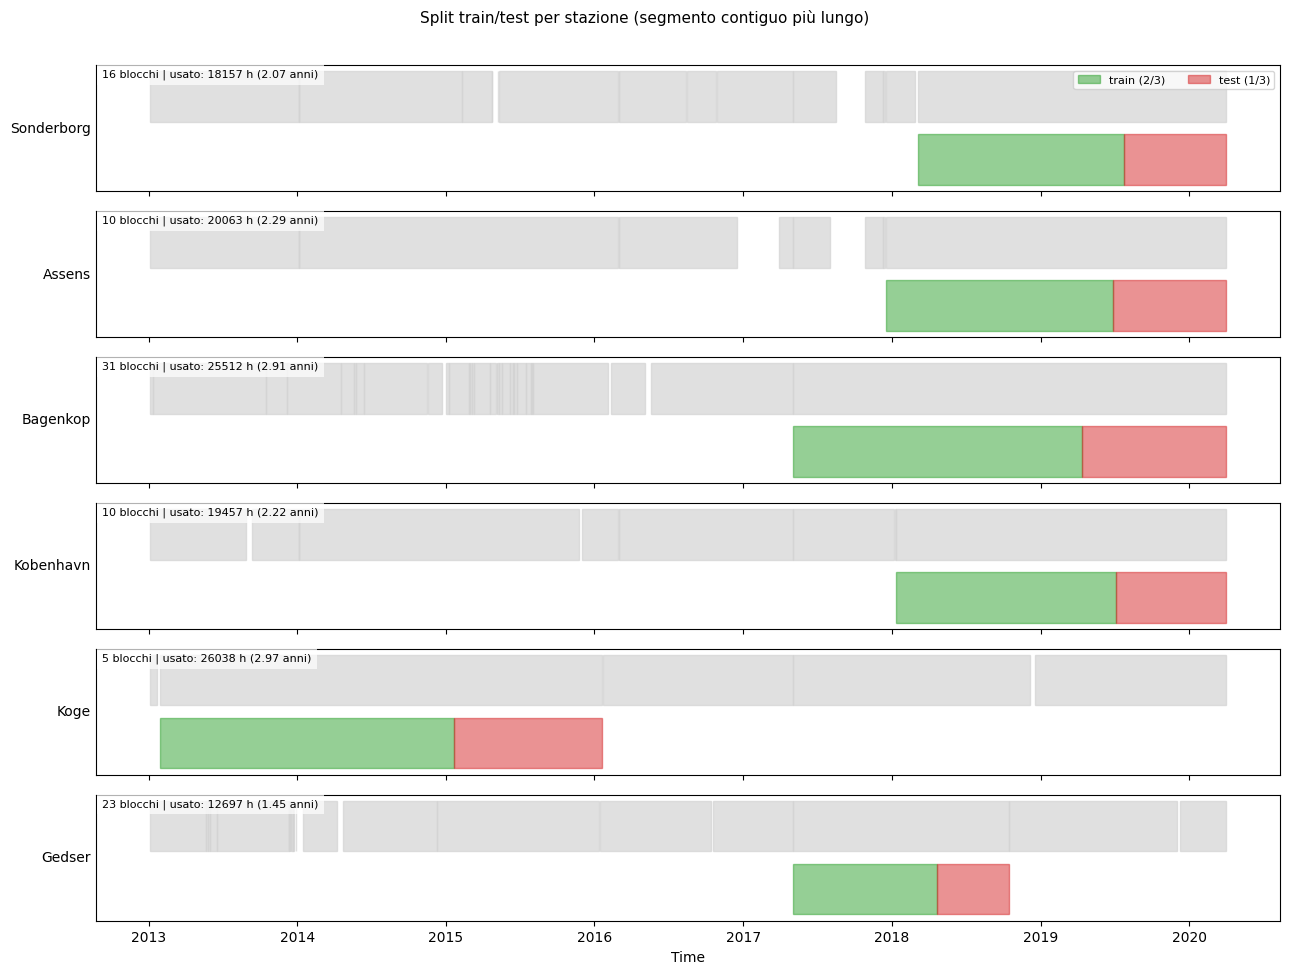


=== Dimensioni matrici (indipendenti per stazione) ===
            n_blocchi  n_train_h  n_test_h X_train_shape X_test_shape train_inizio  train_fine test_inizio   test_fine
stazione                                                                                                              
Sonderborg         16      12104      6053  (12104, 388)  (6053, 388)   2018-03-06  2019-07-23  2019-07-23  2020-03-31
Assens             10      13375      6688  (13375, 388)  (6688, 388)   2017-12-17  2019-06-27  2019-06-27  2020-03-31
Bagenkop           31      17008      8504  (17008, 388)  (8504, 388)   2017-05-04  2019-04-12  2019-04-12  2020-03-31
Kobenhavn          10      12971      6486  (12971, 388)  (6486, 388)   2018-01-11  2019-07-05  2019-07-05  2020-03-31
Koge                5      17358      8680  (17358, 388)  (8680, 388)   2013-01-29  2015-01-22  2015-01-22  2016-01-18
Gedser             23       8464      4233   (8464, 388)  (4233, 388)   2017-05-04  2018-04-21  2018-04-21  201

In [ ]:
# ── Cella 5b: Esempi train/test per stazione ────────────────────────────────
#
# Per ogni stazione, mostra:
#   • tutti i blocchi contigui (gap > 1h li tagliano)
#   • il segmento più lungo che useremo (verde chiaro = train 2/3, rosso = test 1/3)
#   • la dimensione della matrice X (train, test): indipendente per stazione

def find_blocks(idx: pd.DatetimeIndex, freq_h: int = 1):
    """Ritorna lista di (start, end, n_hours) per ogni blocco contiguo."""
    if len(idx) == 0:
        return []
    diff = idx.to_series().diff()
    breaks = (diff != pd.Timedelta(hours=freq_h)).to_numpy()
    starts = np.where(breaks)[0]
    ends   = np.r_[starts[1:] - 1, len(idx) - 1]
    return [(idx[s], idx[e], e - s + 1) for s, e in zip(starts, ends)]


fig, axes = plt.subplots(len(STATIONS), 1, figsize=(13, 1.6 * len(STATIONS)),
                         sharex=True)
summary_rows = []

for ax, stn_name in zip(axes, STATIONS):
    # Carica dati grezzi (no print verboso) e costruisci exog laggiati
    y_stn, exog_raw_stn = load_station(stn_name)
    exog_stn            = build_lagged_exog(exog_raw_stn, EXOG_LAGS)

    # 1) tutti i blocchi contigui (prima del taglio)
    common = y_stn.dropna().index.intersection(exog_stn.dropna().index)
    blocks = find_blocks(common, freq_h=1)

    # 2) segmento contiguo più lungo (= quello che useremo)
    y_use, exog_use = align_and_set_freq(y_stn, exog_stn, 'h')
    n_total = len(y_use)
    n_tr    = int(n_total * TRAIN_FRAC)
    n_te    = n_total - n_tr
    t_tr0, t_tr1 = y_use.index[0],  y_use.index[n_tr - 1]
    t_te0, t_te1 = y_use.index[n_tr], y_use.index[-1]

    # --- Disegno timeline ---
    # tutti i blocchi (grigio chiaro)
    for (b0, b1, _) in blocks:
        ax.axvspan(b0, b1, ymin=0.55, ymax=0.95,
                   color='lightgray', alpha=0.7)
    # train (verde) e test (rosso) sul segmento usato
    ax.axvspan(t_tr0, t_tr1, ymin=0.05, ymax=0.45,
               color='tab:green', alpha=0.5, label='train (2/3)')
    ax.axvspan(t_te0, t_te1, ymin=0.05, ymax=0.45,
               color='tab:red',   alpha=0.5, label='test (1/3)')

    ax.set_yticks([])
    ax.set_ylabel(stn_name, rotation=0, ha='right', va='center', fontsize=10)
    ax.text(0.005, 0.97,
            f'{len(blocks)} blocchi | usato: {n_total} h '
            f'({n_total/24/365:.2f} anni)',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    summary_rows.append({
        'stazione':      stn_name,
        'n_blocchi':     len(blocks),
        'n_train_h':     n_tr,
        'n_test_h':      n_te,
        'X_train_shape': f'({n_tr}, {exog_use.shape[1]})',
        'X_test_shape':  f'({n_te}, {exog_use.shape[1]})',
        'train_inizio':  t_tr0.date(),
        'train_fine':    t_tr1.date(),
        'test_inizio':   t_te0.date(),
        'test_fine':     t_te1.date(),
    })

axes[0].legend(loc='upper right', fontsize=8, ncol=2)
axes[-1].set_xlabel('Time')
fig.suptitle('Split train/test per stazione (segmento contiguo più lungo)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Tabella riassuntiva
df_split = pd.DataFrame(summary_rows).set_index('stazione')
print('\n=== Dimensioni matrici (indipendenti per stazione) ===')
print(df_split.to_string())


R² test (più alto = meglio):

R²:
             h=1h   h=3h   h=6h  h=12h  h=24h
Sonderborg  0.836  0.630  0.350  0.136  0.049
Assens      0.858  0.639  0.424  0.278  0.177
Bagenkop    0.848  0.693  0.467  0.312  0.232
Kobenhavn   0.828  0.530  0.204  0.205  0.103
Koge        0.830  0.655  0.536  0.483  0.439
Gedser      0.729  0.563  0.337  0.153  0.070

RMSE [cm]:
            h=1h  h=3h  h=6h  h=12h  h=24h
Sonderborg  2.49  3.73  4.94   5.70   5.98
Assens      2.25  3.58  4.52   5.06   5.41
Bagenkop    2.23  3.17  4.17   4.74   5.01
Kobenhavn   2.76  4.56  5.94   5.94   6.30
Koge        2.85  4.06  4.71   4.97   5.18
Gedser      2.62  3.33  4.10   4.63   4.86


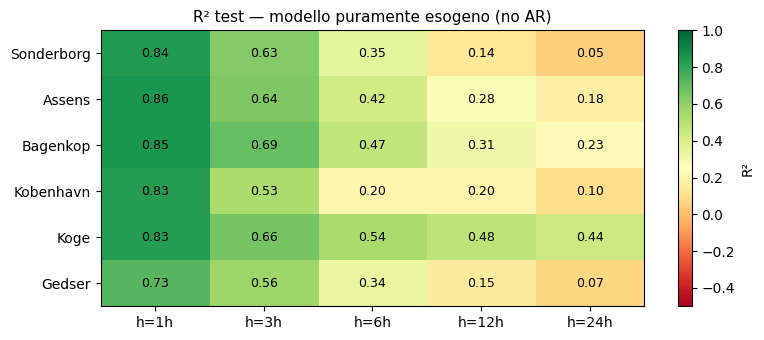

In [ ]:
# ── Cella 6: Tabella riassuntiva R² e RMSE ──────────────────────────────────

print('R² test (più alto = meglio):')
rows_r2   = {stn: {H: ALL_RESULTS[stn][H]['r2']      for H in HORIZONS} for stn in STATIONS}
rows_rmse = {stn: {H: ALL_RESULTS[stn][H]['rmse_cm'] for H in HORIZONS} for stn in STATIONS}

df_r2   = pd.DataFrame(rows_r2).T.rename(columns={H: f'h={H}h' for H in HORIZONS})
df_rmse = pd.DataFrame(rows_rmse).T.rename(columns={H: f'h={H}h' for H in HORIZONS})

print('\nR²:')
print(df_r2.round(3).to_string())
print('\nRMSE [cm]:')
print(df_rmse.round(2).to_string())

# Colormap su R²
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(df_r2.values.astype(float), vmin=-0.5, vmax=1.0,
               cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels([f'h={H}h' for H in HORIZONS])
ax.set_yticks(range(len(STATIONS)))
ax.set_yticklabels(list(STATIONS.keys()))
for i in range(len(STATIONS)):
    for j in range(len(HORIZONS)):
        ax.text(j, i, f"{df_r2.values[i,j]:.2f}",
                ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='R²')
ax.set_title('R² test — modello puramente esogeno (no AR)', fontsize=11)
plt.tight_layout()
plt.show()


PEAK-BASED SCORING  (soglia = p90 di |ε_obs|, same_sign=True)

--- rmse_peak_cm ---
             h=1h   h=3h   h=6h   h=12h   h=24h
Sonderborg  3.032  5.785  8.608  10.345  11.110
Assens      2.810  5.416  7.579   9.110   9.903
Bagenkop    2.754  4.301  6.617   7.980   8.628
Kobenhavn   3.561  6.848  9.275   9.406  10.064
Koge        4.019  6.621  8.226   8.783   9.134
Gedser      4.568  6.298  8.310   9.653  10.295

--- r2_peak ---
             h=1h   h=3h   h=6h  h=12h  h=24h
Sonderborg  0.832  0.389 -0.353 -0.954 -1.254
Assens      0.917  0.693  0.398  0.130 -0.028
Bagenkop    0.549 -0.101 -1.605 -2.789 -3.430
Kobenhavn   0.934  0.757  0.554  0.542  0.475
Koge        0.822  0.516  0.253  0.149  0.079
Gedser      0.734  0.494  0.119 -0.190 -0.353

--- POD ---
             h=1h   h=3h   h=6h  h=12h  h=24h
Sonderborg  0.587  0.337  0.182  0.109  0.053
Assens      0.625  0.390  0.209  0.133  0.076
Bagenkop    0.690  0.495  0.308  0.150  0.103
Kobenhavn   0.570  0.348  0.243  0.223  0.1

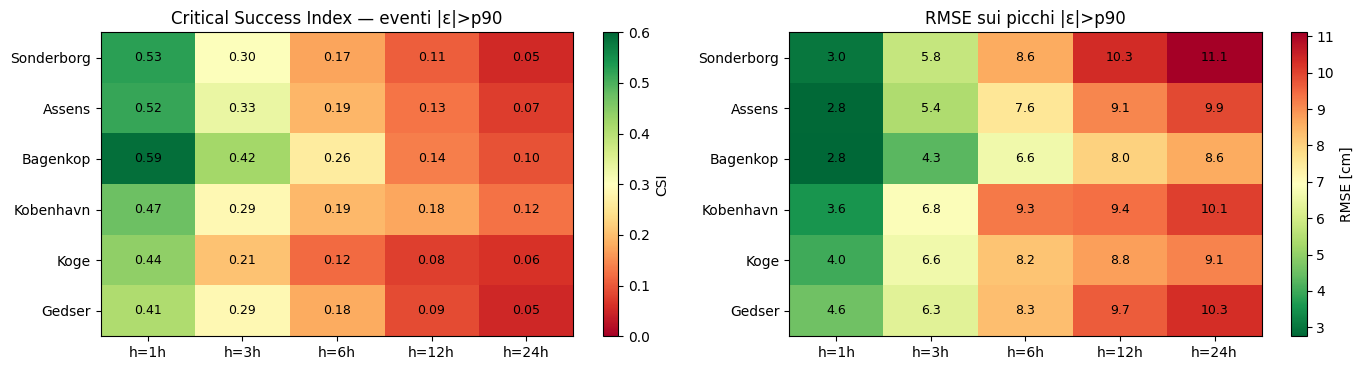


CONFRONTO RMSE globale vs RMSE sui picchi (h=12h)
            RMSE_global_cm  RMSE_peak_cm  soglia_cm  n_peaks   CSI  ratio_pk/glob
stazione                                                                         
Sonderborg            5.70         10.35      11.41      606  0.11           1.82
Assens                5.06          9.11      10.24      669  0.13           1.80
Bagenkop              4.74          7.98      11.78      851  0.14           1.68
Kobenhavn             5.94          9.41      10.99      649  0.18           1.58
Koge                  4.97          8.78      12.33      868  0.08           1.77
Gedser                4.63          9.65       8.32      424  0.09           2.08


In [ ]:
# ── Cella 6b: Peak-based scoring ────────────────────────────────────────────
#
# Le R² globali sono dominate dalle ore "calme". Quello che conta davvero è
# quanto bene predici durante gli EVENTI di surge. Qui calcoliamo metriche
# condizionali sui picchi del test set:
#
#   • soglia adattiva = percentile dell'errore osservato (es. p90 o p95)
#   • RMSE_peak, MAE_peak, bias_peak su {|ε_obs| > soglia}
#   • Skill di detezione eventi: POD, FAR, CSI con classificazione binaria
#
# Definizioni (event = "errore grande in valore assoluto"):
#   TP = obs & pred entrambi sopra soglia (in valore assoluto, stesso segno)
#   FN = obs sopra, pred sotto                  → evento mancato
#   FP = obs sotto, pred sopra                  → falso allarme
#   POD = TP/(TP+FN)   = probabilità di detezione  (1 = perfetto)
#   FAR = FP/(TP+FP)   = falsi allarmi             (0 = perfetto)
#   CSI = TP/(TP+FN+FP) = critical success index   (1 = perfetto)

PEAK_PCTILE = 90       # soglia: percentile sull'|ε_obs| del test set
SAME_SIGN   = True     # se True, il picco predetto deve avere lo stesso segno

def peak_scores(y_true: pd.Series, y_pred: pd.Series,
                pctile: float = 90, same_sign: bool = True):
    """
    Ritorna un dict di metriche peak-based su y_true/y_pred allineati.
    """
    yt = y_true.dropna()
    yp = y_pred.reindex(yt.index).dropna()
    yt = yt.loc[yp.index]
    if len(yt) == 0:
        return {k: np.nan for k in ('thr_cm', 'n_peaks',
                                    'rmse_peak_cm', 'mae_peak_cm',
                                    'bias_peak_cm', 'r2_peak',
                                    'POD', 'FAR', 'CSI')}

    thr = np.percentile(np.abs(yt.values), pctile)

    # Maschere booleane sull'obs e sul pred (in valore assoluto)
    obs_peak  = np.abs(yt.values) > thr
    pred_peak = np.abs(yp.values) > thr

    # Se richiesto, conta come "stesso evento" solo se i segni coincidono
    if same_sign:
        same = np.sign(yt.values) == np.sign(yp.values)
        pred_peak = pred_peak & same

    TP = int(np.sum( obs_peak &  pred_peak))
    FN = int(np.sum( obs_peak & ~pred_peak))
    FP = int(np.sum(~obs_peak &  pred_peak))

    POD = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    FAR = FP / (TP + FP) if (TP + FP) > 0 else np.nan
    CSI = TP / (TP + FN + FP) if (TP + FN + FP) > 0 else np.nan

    # Errori condizionali sui picchi osservati
    yt_pk = yt.values[obs_peak]
    yp_pk = yp.values[obs_peak]
    if len(yt_pk) > 0:
        diff = yt_pk - yp_pk
        rmse_pk = np.sqrt(np.mean(diff**2)) * 100
        mae_pk  = np.mean(np.abs(diff))      * 100
        bias_pk = np.mean(diff)              * 100
        ss_res  = np.sum(diff**2)
        ss_tot  = np.sum((yt_pk - yt_pk.mean())**2)
        r2_pk   = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    else:
        rmse_pk = mae_pk = bias_pk = r2_pk = np.nan

    return {
        'thr_cm':       thr * 100,
        'n_peaks':      int(obs_peak.sum()),
        'rmse_peak_cm': rmse_pk,
        'mae_peak_cm':  mae_pk,
        'bias_peak_cm': bias_pk,
        'r2_peak':      r2_pk,
        'POD':          POD,
        'FAR':          FAR,
        'CSI':          CSI,
    }


# === Calcolo per tutte le stazioni e tutti gli orizzonti ===
peak_results = {}   # peak_results[stn][H] = dict di metriche

for stn in STATIONS:
    peak_results[stn] = {}
    for H in HORIZONS:
        res   = ALL_RESULTS[stn][H]
        y_te  = res['y_test']
        y_pr  = res['preds']['pred']
        peak_results[stn][H] = peak_scores(y_te, y_pr,
                                           pctile=PEAK_PCTILE,
                                           same_sign=SAME_SIGN)

# === Tabelle per orizzonte ===
metrics_to_show = ['rmse_peak_cm', 'r2_peak', 'POD', 'FAR', 'CSI']
print(f'\n{"="*70}')
print(f'PEAK-BASED SCORING  (soglia = p{PEAK_PCTILE} di |ε_obs|, '
      f'same_sign={SAME_SIGN})')
print(f'{"="*70}')

for metric in metrics_to_show:
    rows = {stn: {H: peak_results[stn][H][metric] for H in HORIZONS}
            for stn in STATIONS}
    df_m = pd.DataFrame(rows).T.rename(columns={H: f'h={H}h' for H in HORIZONS})
    print(f'\n--- {metric} ---')
    print(df_m.round(3).to_string())

# === Heatmap CSI (Critical Success Index) ===
rows_csi = {stn: {H: peak_results[stn][H]['CSI'] for H in HORIZONS}
            for stn in STATIONS}
df_csi = pd.DataFrame(rows_csi).T.rename(columns={H: f'h={H}h' for H in HORIZONS})

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))

# CSI
ax = axes[0]
im = ax.imshow(df_csi.values.astype(float), vmin=0, vmax=0.6,
               cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(HORIZONS))); ax.set_xticklabels([f'h={H}h' for H in HORIZONS])
ax.set_yticks(range(len(STATIONS))); ax.set_yticklabels(list(STATIONS.keys()))
for i in range(len(STATIONS)):
    for j in range(len(HORIZONS)):
        v = df_csi.values[i, j]
        ax.text(j, i, f"{v:.2f}" if np.isfinite(v) else '–',
                ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='CSI')
ax.set_title(f'Critical Success Index — eventi |ε|>p{PEAK_PCTILE}')

# RMSE sui picchi
rows_rmse_pk = {stn: {H: peak_results[stn][H]['rmse_peak_cm'] for H in HORIZONS}
                for stn in STATIONS}
df_rmse_pk = pd.DataFrame(rows_rmse_pk).T.rename(
    columns={H: f'h={H}h' for H in HORIZONS})

ax = axes[1]
im = ax.imshow(df_rmse_pk.values.astype(float),
               cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(HORIZONS))); ax.set_xticklabels([f'h={H}h' for H in HORIZONS])
ax.set_yticks(range(len(STATIONS))); ax.set_yticklabels(list(STATIONS.keys()))
for i in range(len(STATIONS)):
    for j in range(len(HORIZONS)):
        v = df_rmse_pk.values[i, j]
        ax.text(j, i, f"{v:.1f}" if np.isfinite(v) else '–',
                ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='RMSE [cm]')
ax.set_title(f'RMSE sui picchi |ε|>p{PEAK_PCTILE}')

plt.tight_layout()
plt.show()

# === Confronto con metrica globale: quanto si "perde" nei picchi? ===
print(f'\n{"="*70}')
print('CONFRONTO RMSE globale vs RMSE sui picchi (h=12h)')
print(f'{"="*70}')
H_cmp = 12
cmp_rows = []
for stn in STATIONS:
    cmp_rows.append({
        'stazione':       stn,
        'RMSE_global_cm': ALL_RESULTS[stn][H_cmp]['rmse_cm'],
        'RMSE_peak_cm':   peak_results[stn][H_cmp]['rmse_peak_cm'],
        'soglia_cm':      peak_results[stn][H_cmp]['thr_cm'],
        'n_peaks':        peak_results[stn][H_cmp]['n_peaks'],
        'CSI':            peak_results[stn][H_cmp]['CSI'],
    })
df_cmp = pd.DataFrame(cmp_rows).set_index('stazione').round(2)
df_cmp['ratio_pk/glob'] = (df_cmp['RMSE_peak_cm']
                           / df_cmp['RMSE_global_cm']).round(2)
print(df_cmp.to_string())


⚠ mismatch nomi/coef: 4657 vs 389 → trunco
n_features = 389, n_coefs = 389
primi nomi: ['lag_1', 'SLP_lag0_step_1', 'SLP_lag1_step_1', 'SLP_lag2_step_1', 'SLP_lag3_step_1']


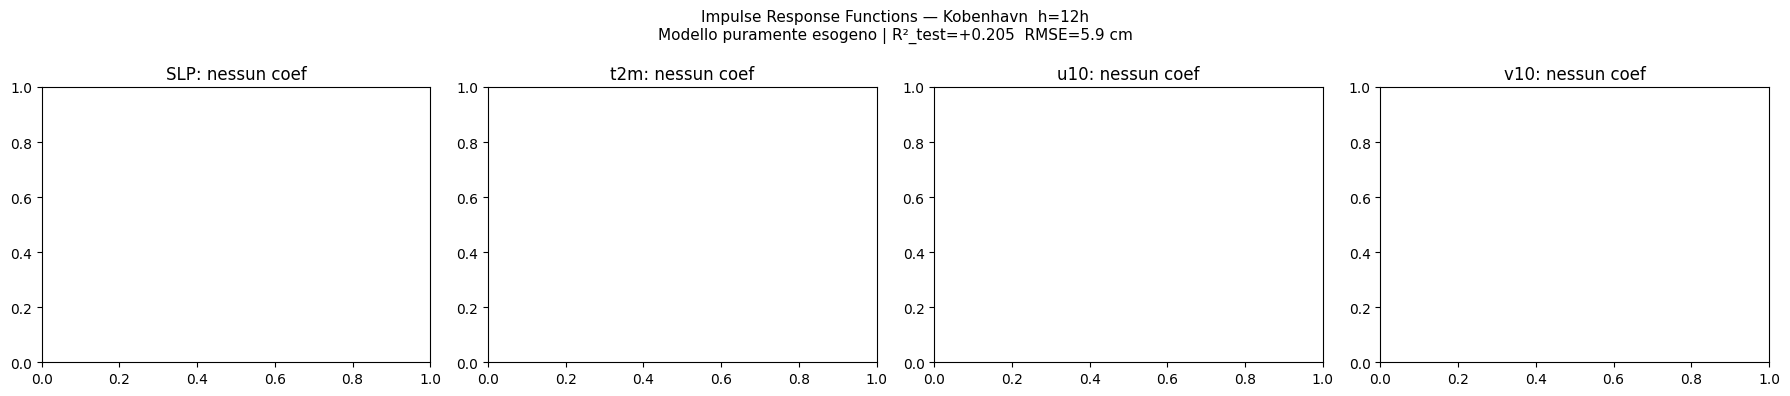

In [ ]:
# ── Cella 7: Impulse Response Functions (IRF) ───────────────────────────────
# Estrae i coefficienti del Ridge per l'orizzonte H_PLOT e li riorganizza
# per (forzante, lag) → risposta impulsiva.

STN_PLOT = 'Kobenhavn'
H_PLOT   = 12

fc_plot = ALL_RESULTS[STN_PLOT][H_PLOT]['forecaster']

# --- 1) Recupera nomi feature usate nel fit (compat. multiple versioni) ---
feat_names = None
for _attr in ('X_train_features_names_out_',
              'X_train_exog_names_out_',
              'exog_names_in_'):
    _val = getattr(fc_plot, _attr, None)
    if _val:
        feat_names = _val
        break

# Per ForecasterDirect i nomi possono essere un dict {step: [...]}
if isinstance(feat_names, dict):
    feat_names = feat_names.get(H_PLOT, next(iter(feat_names.values())))

# Fallback: lag AR ([1]) + colonne dell'exog originale
if feat_names is None:
    feat_names = ['lag_1'] + list(exog_kbh_aligned.columns)
feat_names = list(feat_names)

# --- 2) Recupera i coefficienti del Ridge per l'orizzonte H_PLOT ---
# In skforecast >= 0.13: fc_plot.regressors_ è dict {step: estimator}
_reg = getattr(fc_plot, 'regressors_', None)
if isinstance(_reg, dict) and H_PLOT in _reg:
    coefs = _reg[H_PLOT].coef_
else:
    # vecchie versioni
    coefs = fc_plot.estimators_[H_PLOT - 1].coef_

# Allinea lunghezze (può esserci shift di 1 col se manca/eccede il lag AR)
if len(coefs) != len(feat_names):
    print(f"⚠ mismatch nomi/coef: {len(feat_names)} vs {len(coefs)} → trunco")
    _n = min(len(coefs), len(feat_names))
    coefs, feat_names = coefs[:_n], feat_names[:_n]

print(f"n_features = {len(feat_names)}, n_coefs = {len(coefs)}")
print(f"primi nomi: {feat_names[:5]}")

# --- 3) Ricostruisce la matrice IRF: (forzante × lag) ---
irf_data = {feat: {} for feat in LOCAL_FEATS}
for name_col, beta in zip(feat_names, coefs):
    clean = str(name_col).replace('exog__', '')
    for feat in LOCAL_FEATS:
        prefix = feat + '_lag'
        if clean.startswith(prefix):
            try:
                k = int(clean[len(prefix):])
                irf_data[feat][k] = beta
            except ValueError:
                pass

# --- 4) Plot ---
fig, axes = plt.subplots(1, len(LOCAL_FEATS), figsize=(4.5 * len(LOCAL_FEATS), 4))
colors = {'SLP': '#E74C3C', 't2m': '#3498DB', 'u10': '#2ECC71', 'v10': '#F39C12'}

for ax, feat in zip(axes, LOCAL_FEATS):
    if not irf_data[feat]:
        ax.set_title(f'{feat}: nessun coef')
        continue
    lags_f = sorted(irf_data[feat].keys())
    betas  = [irf_data[feat][k] for k in lags_f]
    c = colors.get(feat, 'k')
    ax.plot(lags_f, betas, color=c, lw=1.8)
    ax.fill_between(lags_f, betas, alpha=0.2, color=c)
    ax.axhline(0, color='black', lw=0.7, ls='--')
    k_peak = lags_f[int(np.argmax(np.abs(betas)))]
    ax.axvline(k_peak, color=c, lw=1, ls=':', alpha=0.8)
    ax.set_title(f'IRF — {feat}  (peak @ lag={k_peak}h)', fontsize=10)
    ax.set_xlabel('Lag k [ore]')
    ax.set_ylabel('β [standardizzato]')

fig.suptitle(
    f'Impulse Response Functions — {STN_PLOT}  h={H_PLOT}h\n'
    f'Modello puramente esogeno | R²_test={ALL_RESULTS[STN_PLOT][H_PLOT]["r2"]:+.3f}'
    f'  RMSE={ALL_RESULTS[STN_PLOT][H_PLOT]["rmse_cm"]:.1f} cm',
    fontsize=11
)
plt.tight_layout()
plt.show()

[Kobenhavn] RefBias = +8.33 cm
  Test predictions: 2019-07-05 18:00:00 → 2020-03-31 23:00:00 (6486 ore)
  ⚠ SURGE_DATE fuori dal test set → uso picco automatico: 2020-03-12
  Finestra: 2020-03-02 → 2020-03-22  | obs=481h, pred=481h


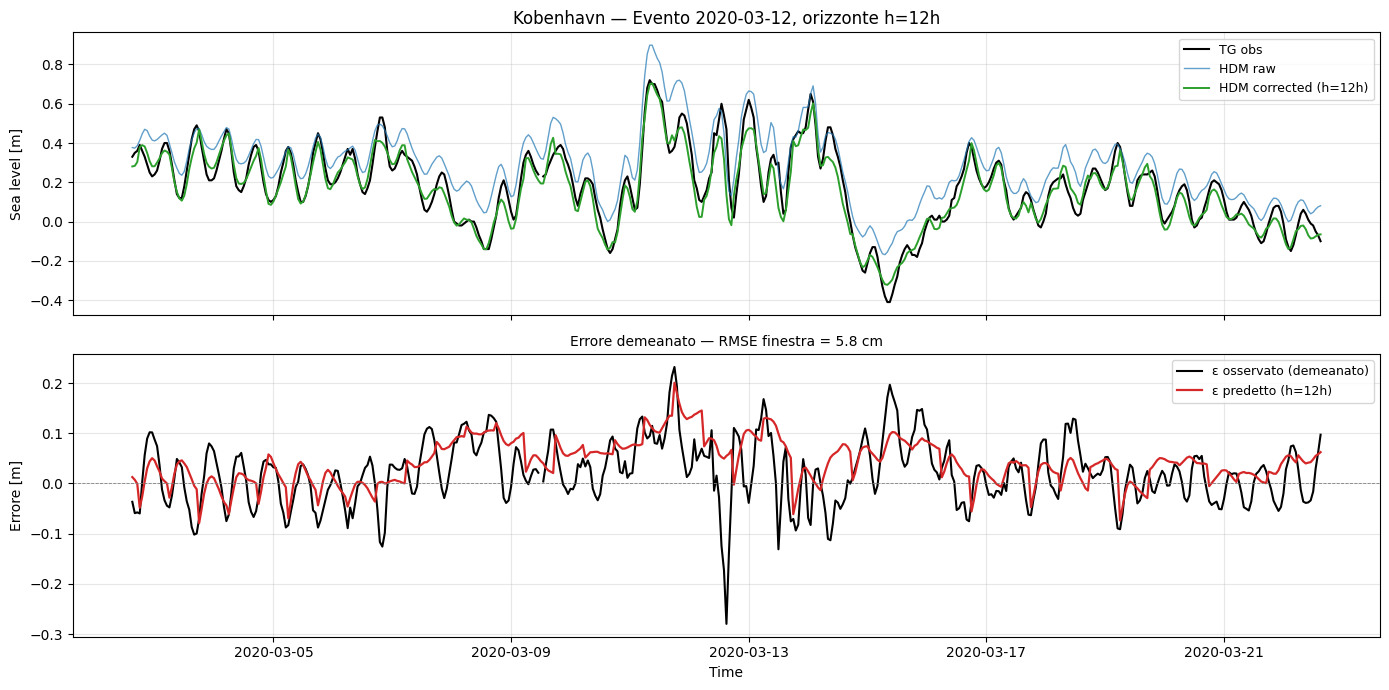

In [ ]:
# ── Cella 8: Visualizzazione di un evento di surge ──────────────────────────
#
# Mostra TG obs, HDM raw, HDM corretto e l'errore residuo
# per una finestra di test che include un evento di surge.
#
# Nota importante: il modello predice l'errore *demeanato* (RefBias rimosso
# in load_station). Per confrontarlo con l'errore osservato dobbiamo o
# togliere il RefBias all'osservato, o riaggiungerlo al predetto.

STN_PLOT  = 'Kobenhavn'
H_PLOT    = 12
SURGE_DATE = '2018-09-20'   # modifica con un evento che conosci
WIN_HOURS  = 240            # finestra: ±10 giorni attorno all'evento

# --- 1) Dati grezzi della stazione + RefBias ---
meta   = STATIONS[STN_PLOT]
df_raw = (pd.read_parquet(DATA_DIR / f"station_{meta['id']}_{STN_PLOT}.parquet")
            .assign(time=lambda x: pd.to_datetime(x['time']))
            .sort_values('time').drop_duplicates('time')
            .set_index('time'))
df_raw['error_m']     = df_raw['forcoast_p82_m'] - df_raw['tg_obs_m']
refbias               = df_raw['error_m'].mean()
df_raw['error_demean']= df_raw['error_m'] - refbias
print(f'[{STN_PLOT}] RefBias = {refbias*100:+.2f} cm')

# --- 2) Predizioni: prendiamo TUTTO il test set, non solo la finestra ---
res        = ALL_RESULTS[STN_PLOT][H_PLOT]
preds_full = res['preds']['pred'].dropna()
print(f"  Test predictions: {preds_full.index.min()} → {preds_full.index.max()} "
      f"({len(preds_full)} ore)")

# --- 3) Se SURGE_DATE è fuori dal test set, uso il picco più grande del test ---
t_center = pd.Timestamp(SURGE_DATE)
if not (preds_full.index.min() <= t_center <= preds_full.index.max()):
    err_test = df_raw['error_demean'].reindex(preds_full.index).abs()
    t_center = err_test.idxmax()
    print(f"  ⚠ SURGE_DATE fuori dal test set → uso picco automatico: "
          f"{t_center.date()}")

t_start = t_center - pd.Timedelta(hours=WIN_HOURS)
t_end   = t_center + pd.Timedelta(hours=WIN_HOURS)

df_ev    = df_raw.loc[t_start:t_end]
preds_ev = preds_full.loc[t_start:t_end]
print(f"  Finestra: {t_start.date()} → {t_end.date()}  "
      f"| obs={len(df_ev)}h, pred={len(preds_ev)}h")

# --- 4) Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Pannello 1: Sea level assoluto
ax1.plot(df_ev.index, df_ev['tg_obs_m'],       color='black',    lw=1.5,
         label='TG obs')
ax1.plot(df_ev.index, df_ev['forcoast_p82_m'], color='tab:blue', lw=1.0,
         label='HDM raw', alpha=0.7)
# HDM corretto = HDM raw - (predizione_errore + RefBias)
hdm_corr_idx = df_ev.index.intersection(preds_ev.index)
if len(hdm_corr_idx) > 0:
    hdm_corr = (df_ev.loc[hdm_corr_idx, 'forcoast_p82_m']
                - (preds_ev.loc[hdm_corr_idx] + refbias))
    ax1.plot(hdm_corr_idx, hdm_corr, color='tab:green', lw=1.4,
             label=f'HDM corrected (h={H_PLOT}h)')
ax1.set_ylabel('Sea level [m]')
ax1.legend(fontsize=9)
ax1.set_title(f'{STN_PLOT} — Evento {t_center.date()}, orizzonte h={H_PLOT}h')
ax1.grid(alpha=0.3)

# Pannello 2: Errore demeanato osservato vs predetto (stessa scala del modello)
ax2.plot(df_ev.index, df_ev['error_demean'], color='black', lw=1.5,
         label='ε osservato (demeanato)')
if len(hdm_corr_idx) > 0:
    ax2.plot(hdm_corr_idx, preds_ev.loc[hdm_corr_idx],
             color='tab:red', lw=1.6, label=f'ε predetto (h={H_PLOT}h)')
    # Banda di errore residuo
    resid = df_ev.loc[hdm_corr_idx, 'error_demean'] - preds_ev.loc[hdm_corr_idx]
    rmse_win = np.sqrt(np.mean(resid**2)) * 100
    ax2.set_title(f'Errore demeanato — RMSE finestra = {rmse_win:.1f} cm',
                  fontsize=10)
else:
    ax2.set_title('⚠ Nessuna predizione nella finestra (fuori dal test set)',
                  fontsize=10)
ax2.axhline(0, color='grey', lw=0.6, ls='--')
ax2.set_ylabel('Errore [m]')
ax2.set_xlabel('Time')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
